# MA429 Summative Project (Section 6)

- **Input Dataset**: "station_hour_features.parquet"
- **Final Output**:  Demand (Inflow/Outflow) prediction result
- **Section 6 (LSTM)**: This notebook runs **LSTM only** with a **single time step** (target_outflow_t1, target_inflow_t1) and **full feature set A** (base + all heterogeneity) on the **sampled dataset (first 30% time span)**. Train/val/test split and metrics (MAE, RMSE, WAPE, R²) match Section 5.

---
## 6 Demand Forecasting: LSTM




### 6.0 Load station-hour feature dataset

Load the station-hour panel. Set `SOURCE = "drive"` on Colab or `SOURCE = "local"` locally.


In [37]:
import numpy as np
import pandas as pd
import os
import json
from datetime import datetime
from typing import Dict, List, Optional, Tuple, Any
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Mount Google Drive
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    pass  # not in Colab

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
# Choose one: "drive" = Google Drive (Colab), "local" = local file
SOURCE = "drive" 

if SOURCE == "drive":
    parquet_path = "/content/drive/MyDrive/station_hour_features.parquet"
else:
    parquet_path = "station_hour_features.parquet"

# Load full dataset
df = pd.read_parquet(parquet_path)
print("Loaded shape (full):", df.shape)

# --- Use only the first 30% of the time span for this notebook ---
# Sort by time and build unique (date, hour) grid
_df_time = df.sort_values(["date", "hour"]).reset_index(drop=True)
uniq_time = _df_time[["date", "hour"]].drop_duplicates().sort_values(["date", "hour"]).reset_index(drop=True)
T_total = len(uniq_time)
cutoff_T = int(T_total * 0.30)
if cutoff_T < 1:
    cutoff_T = 1
uniq_time["_time_idx"] = range(T_total)

# Merge time index back and keep only first 30% of time steps
_df_time = _df_time.merge(uniq_time, on=["date", "hour"], how="left")
_df_time = _df_time[_df_time["_time_idx"] < cutoff_T].drop(columns=["_time_idx"]).reset_index(drop=True)

print(f"Using first 30% of time steps: {cutoff_T}/{T_total}")
print("Subsampled date range:", _df_time["date"].min(), "to", _df_time["date"].max())

# Replace original df with time-subsampled df
df = _df_time
print("Loaded shape (time-subsampled 30%):", df.shape)

Loaded shape (full): (21132864, 53)
Using first 30% of time steps: 3283/10944
Subsampled date range: 2024-01-01 to 2024-05-16
Loaded shape (time-subsampled 30%): (6339473, 53)


In [39]:
df.tail()

,station_id,date,hour,outflow,inflow,day_of_week,is_weekend,month,sin_hour,cos_hour,...,casual_ratio,cluster_0_ratio,cluster_1_ratio,cluster_2_ratio,cluster_3_ratio,cluster_4_ratio,cluster_5_ratio,cluster_6_ratio,cluster_7_ratio,cluster_8_ratio
6339468,chargingstx1,2024-05-16,18,3,6,3,0,5,-1.0,-1.836970e-16,...,0.333333,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6339469,chargingstx2,2024-05-16,18,1,1,3,0,5,-1.0,-1.836970e-16,...,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6339470,chargingstx3,2024-05-16,18,2,6,3,0,5,-1.0,-1.836970e-16,...,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6339471,chargingstx4,2024-05-16,18,2,1,3,0,5,-1.0,-1.836970e-16,...,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6339472,chargingstx5,2024-05-16,18,1,0,3,0,5,-1.0,-1.836970e-16,...,0.000000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


### 6.1 Config and constants (LSTM)

Single-step targets (target_outflow_t1, target_inflow_t1), full feature set (base_all_heterogeneity), temporal split (70% / 15% / 15%), sequence length, and LSTM hyperparameters (hidden size, layers, dropout, epochs, batch size, learning rate).


In [40]:
# --- Config and constants (LSTM only) ---

# Single-step prediction target
DEFAULT_TARGETS = ["target_outflow_t1", "target_inflow_t1"]

# Full feature set only
RUN_FEATURE_SET = "base_all_heterogeneity"

# Temporal split: train 70%, val 15%, test 15%
SPLIT_TRAIN_RATIO = 0.70
SPLIT_VAL_RATIO = 0.15
SPLIT_TEST_RATIO = 0.15
assert abs(SPLIT_TRAIN_RATIO + SPLIT_VAL_RATIO + SPLIT_TEST_RATIO - 1.0) < 1e-9

# Feature Set A and ablation names for LSTM
FEATURE_SET_A = "A"
ABLATION_BASE_ONLY = "base_only"
ABLATION_MEMBER_CASUAL = "base_member_casual"
ABLATION_CLUSTER = "base_cluster"
ABLATION_ALL_HET = "base_all_heterogeneity"
RNN_ABLATIONS = [ABLATION_ALL_HET] 

# Sequence length and default LSTM config
DEFAULT_SEQ_LEN = 24
DEFAULT_LSTM_CONFIG = {
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0.4,
    "epochs": 20,
    "batch_size": 256,
    "learning_rate": 0.01,
    "early_stopping_patience": 10,
}

# When using Colab with SOURCE="drive", save results to Google Drive
if "SOURCE" in dir() and SOURCE == "drive":
    RESULTS_DIR = "/content/drive/MyDrive/section6_results"
else:
    RESULTS_DIR = "section6_results"
os.makedirs(RESULTS_DIR, exist_ok=True)
LOG_DIR = os.path.join(RESULTS_DIR, "logs")
CONFIG_DIR = os.path.join(RESULTS_DIR, "configs")
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(CONFIG_DIR, exist_ok=True)

### 6.2 Feature set definitions (LSTM)

Base = flow + time + station; heterogeneity (member_ratio, casual_ratio, cluster_ratio) added for the full set. This notebook runs only the full feature set (base_all_heterogeneity).


In [41]:
# --- Feature set definitions (LSTM: A and ablations) ---

BASE_FLOW = ["outflow", "inflow"]
BASE_TIME = ["hour", "day_of_week", "is_weekend", "month", "sin_hour", "cos_hour"]
BASE_STATION = ["lat", "lng", "historical_mean_outflow", "historical_mean_inflow"]
HETEROGENEITY_MEMBER_CASUAL = ["member_ratio", "casual_ratio"]
HETEROGENEITY_CLUSTER = [f"cluster_{i}_ratio" for i in range(9)]
HETEROGENEITY_ALL = HETEROGENEITY_MEMBER_CASUAL + HETEROGENEITY_CLUSTER

def get_feature_set_A_columns(all_columns: List[str]) -> List[str]:
    """Feature Set A: base + all heterogeneity."""
    base = [c for c in (BASE_FLOW + BASE_TIME + BASE_STATION + HETEROGENEITY_ALL) if c in all_columns]
    return base

def get_rnn_ablation_feature_columns(all_columns: List[str], ablation: str) -> List[str]:
    """Ablation feature sets for LSTM: base_only, base_member_casual, base_cluster, base_all_heterogeneity."""
    base = [c for c in (BASE_FLOW + BASE_TIME + BASE_STATION) if c in all_columns]
    if ablation == ABLATION_BASE_ONLY:
        return base
    if ablation == ABLATION_MEMBER_CASUAL:
        return base + [c for c in HETEROGENEITY_MEMBER_CASUAL if c in all_columns]
    if ablation == ABLATION_CLUSTER:
        return base + [c for c in HETEROGENEITY_CLUSTER if c in all_columns]
    if ablation == ABLATION_ALL_HET:
        return base + [c for c in HETEROGENEITY_ALL if c in all_columns]
    raise ValueError(f"Unknown ablation: {ablation}")

def get_feature_columns_for_rnn(df_columns: List[str], ablation: str) -> List[str]:
    """Return feature column list for LSTM given ablation name."""
    return get_rnn_ablation_feature_columns(df_columns, ablation)

### 6.3 Temporal train/validation/test split

Split the sorted (date, hour) panel by row index into train (70%), validation (15%), and test (15%). Same logic as Section 5; no shuffling to avoid leakage.


In [42]:
# --- Temporal split (shared with Section 5) ---

def temporal_train_val_test_split(
    df: pd.DataFrame,
    train_ratio: float = SPLIT_TRAIN_RATIO,
    val_ratio: float = SPLIT_VAL_RATIO,
    test_ratio: float = SPLIT_TEST_RATIO,
    time_col: Optional[str] = None,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Split dataframe by temporal order (first N% rows = train, next = val, last = test).
    Uses row index only to avoid any future information leakage.
    
    """
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9
    n = len(df)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    n_test = n - n_train - n_val
    train_df = df.iloc[:n_train]
    val_df = df.iloc[n_train : n_train + n_val]
    test_df = df.iloc[n_train + n_val :]
    return train_df, val_df, test_df

def get_split_indices(
    n: int,
    train_ratio: float = SPLIT_TRAIN_RATIO,
    val_ratio: float = SPLIT_VAL_RATIO,
    test_ratio: float = SPLIT_TEST_RATIO,
) -> Tuple[slice, slice, slice]:
    """Return (train_slice, val_slice, test_slice) for use with iloc or arrays."""
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    n_test = n - n_train - n_val
    return slice(0, n_train), slice(n_train, n_train + n_val), slice(n_train + n_val, n)

### 6.4 Evaluation metrics and result aggregation

MAE, RMSE, WAPE, and R². `compute_metrics` returns all four; `append_result` appends a row to the results list for each model/target/split.


In [43]:
# --- Evaluation metrics (shared with Section 5) ---

def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def wape(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-8) -> float:
    """Weighted Absolute Percentage Error: sum|y_true - y_pred| / sum|y_true|."""
    s_abs_diff = np.sum(np.abs(y_true - y_pred))
    s_abs_true = np.sum(np.abs(y_true)) + eps
    return float(s_abs_diff / s_abs_true)

def r2(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Coefficient of determination: 1 - SS_res/SS_tot."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot < 1e-12:
        return 0.0
    return float(1.0 - ss_res / ss_tot)

def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return {"MAE": mae(y_true, y_pred), "RMSE": rmse(y_true, y_pred), "WAPE": wape(y_true, y_pred), "R2": r2(y_true, y_pred)}

def append_result(
    results_list: List[Dict],
    model_name: str,
    target: str,
    feature_set: str,
    split: str,
    metrics: Dict[str, float],
    extra: Optional[Dict] = None,
) -> None:
    row = {"model": model_name, "target": target, "feature_set": feature_set, "split": split, **metrics}
    if extra:
        row.update(extra)
    results_list.append(row)

### 6.5 Sequence data pipeline (LSTM)

Build (X, y) for train, val, and test from the split DataFrames. Each sample is a sequence of `seq_len` time steps.


In [44]:
# --- Sequence pipeline for LSTM ---

def build_sequence_splits(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    feature_cols: List[str],
    target_col: str,
    seq_len: int,
    date_col: str = "date",
    hour_col: str = "hour",
    station_col: str = "station_id",
    return_test_meta: bool = False,
) -> Tuple:
    """
    Build (X, y) for train, val, test. X shape: (n_samples, seq_len, n_features), y: (n_samples,).
    Return test_meta_df (station_id, date, hour, target) for each test sample.
    """
    full = pd.concat([train_df, val_df, test_df], axis=0)
    uniq = full[[date_col, hour_col]].drop_duplicates().sort_values([date_col, hour_col]).reset_index(drop=True)
    uniq["_time_idx"] = range(len(uniq))
    full = full.merge(uniq, on=[date_col, hour_col], how="left")
    T = len(uniq)
    t_train = int(T * SPLIT_TRAIN_RATIO)
    t_val = int(T * SPLIT_VAL_RATIO)
    train_times = set(range(0, t_train))
    val_times = set(range(t_train, t_train + t_val))
    test_times = set(range(t_train + t_val, T))

    full = full.dropna(subset=[target_col]).sort_values([station_col, date_col, hour_col])
    X_train_list, y_train_list = [], []
    X_val_list, y_val_list = [], []
    X_test_list, y_test_list = [], []
    test_meta_list = []

    for _sid, grp in full.groupby(station_col):
        grp = grp.sort_values([date_col, hour_col])
        if len(grp) < seq_len + 1:
            continue
        feats = grp[feature_cols].values.astype(np.float32)
        tgt = grp[target_col].values.astype(np.float32)
        times = grp["_time_idx"].values
        for i in range(seq_len, len(grp)):
            x = feats[i - seq_len : i]
            y = tgt[i - 1]
            ti = int(times[i])
            if ti in train_times:
                X_train_list.append(x)
                y_train_list.append(y)
            elif ti in val_times:
                X_val_list.append(x)
                y_val_list.append(y)
            elif ti in test_times:
                X_test_list.append(x)
                y_test_list.append(y)
                if return_test_meta:
                    test_meta_list.append({station_col: _sid, date_col: grp[date_col].iloc[i], hour_col: grp[hour_col].iloc[i], target_col: y})

    def _stack(X_list, y_list):
        if not X_list:
            return np.zeros((0, seq_len, len(feature_cols)), dtype=np.float32), np.zeros(0, dtype=np.float32)
        return np.stack(X_list, axis=0), np.array(y_list, dtype=np.float32)

    out = (_stack(X_train_list, y_train_list), _stack(X_val_list, y_val_list), _stack(X_test_list, y_test_list))
    if return_test_meta:
        test_meta_df = pd.DataFrame(test_meta_list) if test_meta_list else pd.DataFrame(columns=[station_col, date_col, hour_col, target_col])
        return out + (test_meta_df,)
    return out

### 6.6 Model wrappers (LSTM)

SeqRegressor: LSTM sequence-to-one regressor. `train_predict_lstm` trains for a fixed number of epochs and returns (val_pred, test_pred, model, history_or_None). 


In [45]:
# --- Model wrappers (LSTM with epoch logging) ---

import copy

def _get_device():
    """CUDA > MPS (Apple Silicon) > CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

class SeqRegressor(nn.Module):
    """LSTM sequence-to-one regressor."""
    def __init__(self, input_size: int, hidden_size: int, num_layers: int, dropout: float):
        super().__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

def _train_epoch(model, loader, criterion, optimizer, device, log_callback=None):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg = total_loss / len(loader)
    return avg

def _predict_in_batches(model, X: np.ndarray, device, batch_size: int = 2048):
    """Run model on X in batches to avoid GPU OOM."""
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, X.shape[0], batch_size):
            batch = torch.from_numpy(X[i : i + batch_size]).float().to(device)
            preds.append(model(batch).cpu().numpy())
    return np.concatenate(preds, axis=0)

def train_predict_lstm(
    X_train: np.ndarray, y_train: np.ndarray,
    X_val: np.ndarray, y_val: np.ndarray,
    X_test: np.ndarray,
    feature_dim: int,
    config: Optional[Dict] = None,
    log_callback: Optional[Any] = None,
    return_history: bool = False,
) -> Tuple:
    """Train LSTM"""
    cfg = dict(DEFAULT_LSTM_CONFIG)
    if config:
        cfg.update(config)
    device = _get_device()
    model = SeqRegressor(feature_dim, cfg["hidden_size"], cfg["num_layers"], cfg["dropout"]).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["learning_rate"])
    train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
    train_loader = DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=True)
    hist = {"train_loss": [], "val_loss": [], "val_rmse": [], "val_r2": []} if return_history else None
    _d = {"X_train_shape": list(X_train.shape), "X_val_shape": list(X_val.shape), "X_test_shape": list(X_test.shape), "X_train_GB": float(X_train.nbytes) / 1e9, "X_val_GB": float(X_val.nbytes) / 1e9, "X_test_GB": float(X_test.nbytes) / 1e9}
    try:
        with open("/Users/gurunchi/Desktop/MA429 Summative Project Coding/.cursor/debug-6201b4.log", "a") as _f:
            _f.write(__import__("json").dumps({"hypothesisId": "H1", "message": "LSTM input shapes", "data": _d, "timestamp": __import__("time").time()}) + "\n")
    except Exception:
        pass
    patience = cfg.get("early_stopping_patience", 15)
    best_val_rmse = float("inf")
    best_state = None
    epochs_no_improve = 0
    if log_callback:
        log_callback(f"LSTM: training up to {cfg['epochs']} epochs (early_stopping_patience={patience})...")
    for ep in range(cfg["epochs"]):
        avg_loss = _train_epoch(model, train_loader, criterion, optimizer, device, log_callback)
        model.eval()
        if ep == 0:
            _d2 = {"epoch": 0, "X_val_GB": float(X_val.nbytes) / 1e9, "X_val_shape": list(X_val.shape)}
            try:
                with open("/Users/gurunchi/Desktop/MA429 Summative Project Coding/.cursor/debug-6201b4.log", "a") as _f:
                    _f.write(__import__("json").dumps({"hypothesisId": "H1", "message": "LSTM about to put X_val on GPU (batched)", "data": _d2, "timestamp": __import__("time").time()}) + "\n")
            except Exception:
                pass
        vp = _predict_in_batches(model, X_val, device)
        val_rmse_i = rmse(y_val, vp)
        val_loss_i = float(np.mean((y_val - vp) ** 2))  # MSE
        val_r2_i = r2(y_val, vp)
        if return_history:
            hist["train_loss"].append(avg_loss)
            hist["val_loss"].append(val_loss_i)
            hist["val_rmse"].append(val_rmse_i)
            hist["val_r2"].append(val_r2_i)
        if log_callback:
            log_callback(f"  Epoch {ep+1}/{cfg['epochs']}  train_loss={avg_loss:.6f}  val_loss={val_loss_i:.6f}  val_rmse={val_rmse_i:.6f}  val_r2={val_r2_i:.4f}")
        model.train()
        if val_rmse_i < best_val_rmse:
            best_val_rmse = val_rmse_i
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        if epochs_no_improve >= patience:
            if log_callback:
                log_callback(f"  Early stopping at epoch {ep + 1}")
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    val_pred = _predict_in_batches(model, X_val, device)
    test_pred = _predict_in_batches(model, X_test, device)
    return val_pred, test_pred, model, hist



In [46]:
# Check which device will be used for LSTM
print("_get_device() ->", _get_device())

_get_device() -> cuda


### 6.7 Run experiments

Sort data by (date, hour), split into train/val/test (full dataset). Run LSTM only for the single-step targets and full feature set only. Capture per-epoch train loss and validation RMSE/R² for the curves in Section 6.8. Log: `section6_results/logs/training_iteration_log.txt`.


In [47]:
# ---- Run experiments: single-step targets, full feature set, full dataset ---
df_sorted = df.sort_values(["date", "hour"]).reset_index(drop=True)
train_df, val_df, test_df = temporal_train_val_test_split(df_sorted)

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(CONFIG_DIR, exist_ok=True)

all_results = []
run_config = {
    "split_ratios": {"train": SPLIT_TRAIN_RATIO, "val": SPLIT_VAL_RATIO, "test": SPLIT_TEST_RATIO},
    "targets": DEFAULT_TARGETS,
    "ablations": RNN_ABLATIONS,
    "timestamp": datetime.now().isoformat(),
}
cols_by_ablation = {ablation: get_feature_columns_for_rnn(list(df_sorted.columns), ablation) for ablation in RNN_ABLATIONS}
train_log_path = os.path.join(LOG_DIR, "training_iteration_log.txt")
train_log = open(train_log_path, "w")
def log_iter(msg):
    print(msg)
    train_log.write(msg + "\n")
    train_log.flush()
log_iter("Section 6 - LSTM run started " + datetime.now().isoformat())
seq_len = DEFAULT_SEQ_LEN
histories = {"LSTM": {}}  
test_predictions = {}  

Section 6 - LSTM run started 2026-03-20T16:50:00.638450


In [48]:
# Run LSTM for every target × every ablation; record iteration (epochs) in log
for target in DEFAULT_TARGETS:
    for ablation in RNN_ABLATIONS:
        feature_cols = cols_by_ablation[ablation]
        (X_tr, y_tr), (X_va, y_va), (X_te, y_te), test_meta_df = build_sequence_splits(
            train_df, val_df, test_df, feature_cols, target, seq_len, return_test_meta=True
        )
        if X_tr.shape[0] == 0:
            log_iter(f"Warning: no train samples for target={target} ablation={ablation}; skip.")
            continue
        feat_dim = X_tr.shape[2]
        log_iter("")
        log_iter(f"--- target={target} | ablation={ablation} | n_train={len(y_tr)} ---")
        # LSTM (with history for loss/accuracy curves)
        log_iter(f"[LSTM] target={target} ablation={ablation}")
        vp, tp, _, lstm_hist = train_predict_lstm(X_tr, y_tr, X_va, y_va, X_te, feat_dim, log_callback=log_iter, return_history=True)
        if lstm_hist is not None:
            histories["LSTM"][target] = lstm_hist
        append_result(all_results, "LSTM", target, ablation, "val", compute_metrics(y_va, vp))
        append_result(all_results, "LSTM", target, ablation, "test", compute_metrics(y_te, tp))
        m = test_meta_df[["station_id", "date", "hour", target]].copy()
        m["pred"] = tp
        test_predictions[("LSTM", target)] = m

train_log.close()



--- target=target_outflow_t1 | ablation=base_all_heterogeneity | n_train=4391094 ---
[LSTM] target=target_outflow_t1 ablation=base_all_heterogeneity
LSTM: training up to 20 epochs (early_stopping_patience=10)...
  Epoch 1/20  train_loss=0.225368  val_loss=0.489216  val_rmse=0.699440  val_r2=0.5261
  Epoch 2/20  train_loss=0.220906  val_loss=0.510774  val_rmse=0.714685  val_r2=0.5052
  Epoch 3/20  train_loss=0.214654  val_loss=0.478151  val_rmse=0.691485  val_r2=0.5368
  Epoch 4/20  train_loss=0.212886  val_loss=0.536083  val_rmse=0.732177  val_r2=0.4807
  Epoch 5/20  train_loss=0.218199  val_loss=0.496811  val_rmse=0.704848  val_r2=0.5188
  Epoch 6/20  train_loss=0.213624  val_loss=0.506831  val_rmse=0.711921  val_r2=0.5091
  Epoch 7/20  train_loss=0.215175  val_loss=0.466963  val_rmse=0.683347  val_r2=0.5477
  Epoch 8/20  train_loss=0.214314  val_loss=0.501157  val_rmse=0.707924  val_r2=0.5146
  Epoch 9/20  train_loss=0.218514  val_loss=0.487476  val_rmse=0.698195  val_r2=0.5278
  Ep

In [49]:
# Save run config and full results
run_config["cols_by_ablation"] = {k: v for k, v in cols_by_ablation.items()}
with open(os.path.join(CONFIG_DIR, "run_config.json"), "w") as f:
    json.dump(run_config, f, indent=2)
results_df = pd.DataFrame(all_results)
results_df.to_csv(os.path.join(RESULTS_DIR, "baseline_results.csv"), index=False)


### 6.8 Evaluation metrics and vilsualization

Display the validation set and test set evaluation metrics (MAE, RMSE, WAPE, R²), plot LSTM train loss and validation loss (MSE) vs epoch, and plot total flow (actual vs predicted) for a few test period and all stations by hour.


In [50]:
# --- Full results (validation + test) ---
display(results_df)

,model,target,feature_set,split,MAE,RMSE,WAPE,R2
0,LSTM,target_outflow_t1,base_all_heterogeneity,val,0.188624,0.683347,0.860644,0.547681
1,LSTM,target_outflow_t1,base_all_heterogeneity,test,0.218805,0.780124,0.813559,0.564592
2,LSTM,target_inflow_t1,base_all_heterogeneity,val,0.238157,0.708892,1.086653,0.519953
3,LSTM,target_inflow_t1,base_all_heterogeneity,test,0.272288,0.811909,1.012419,0.532358


LSTM: All stations — total flow by hour (Actual vs Predicted)


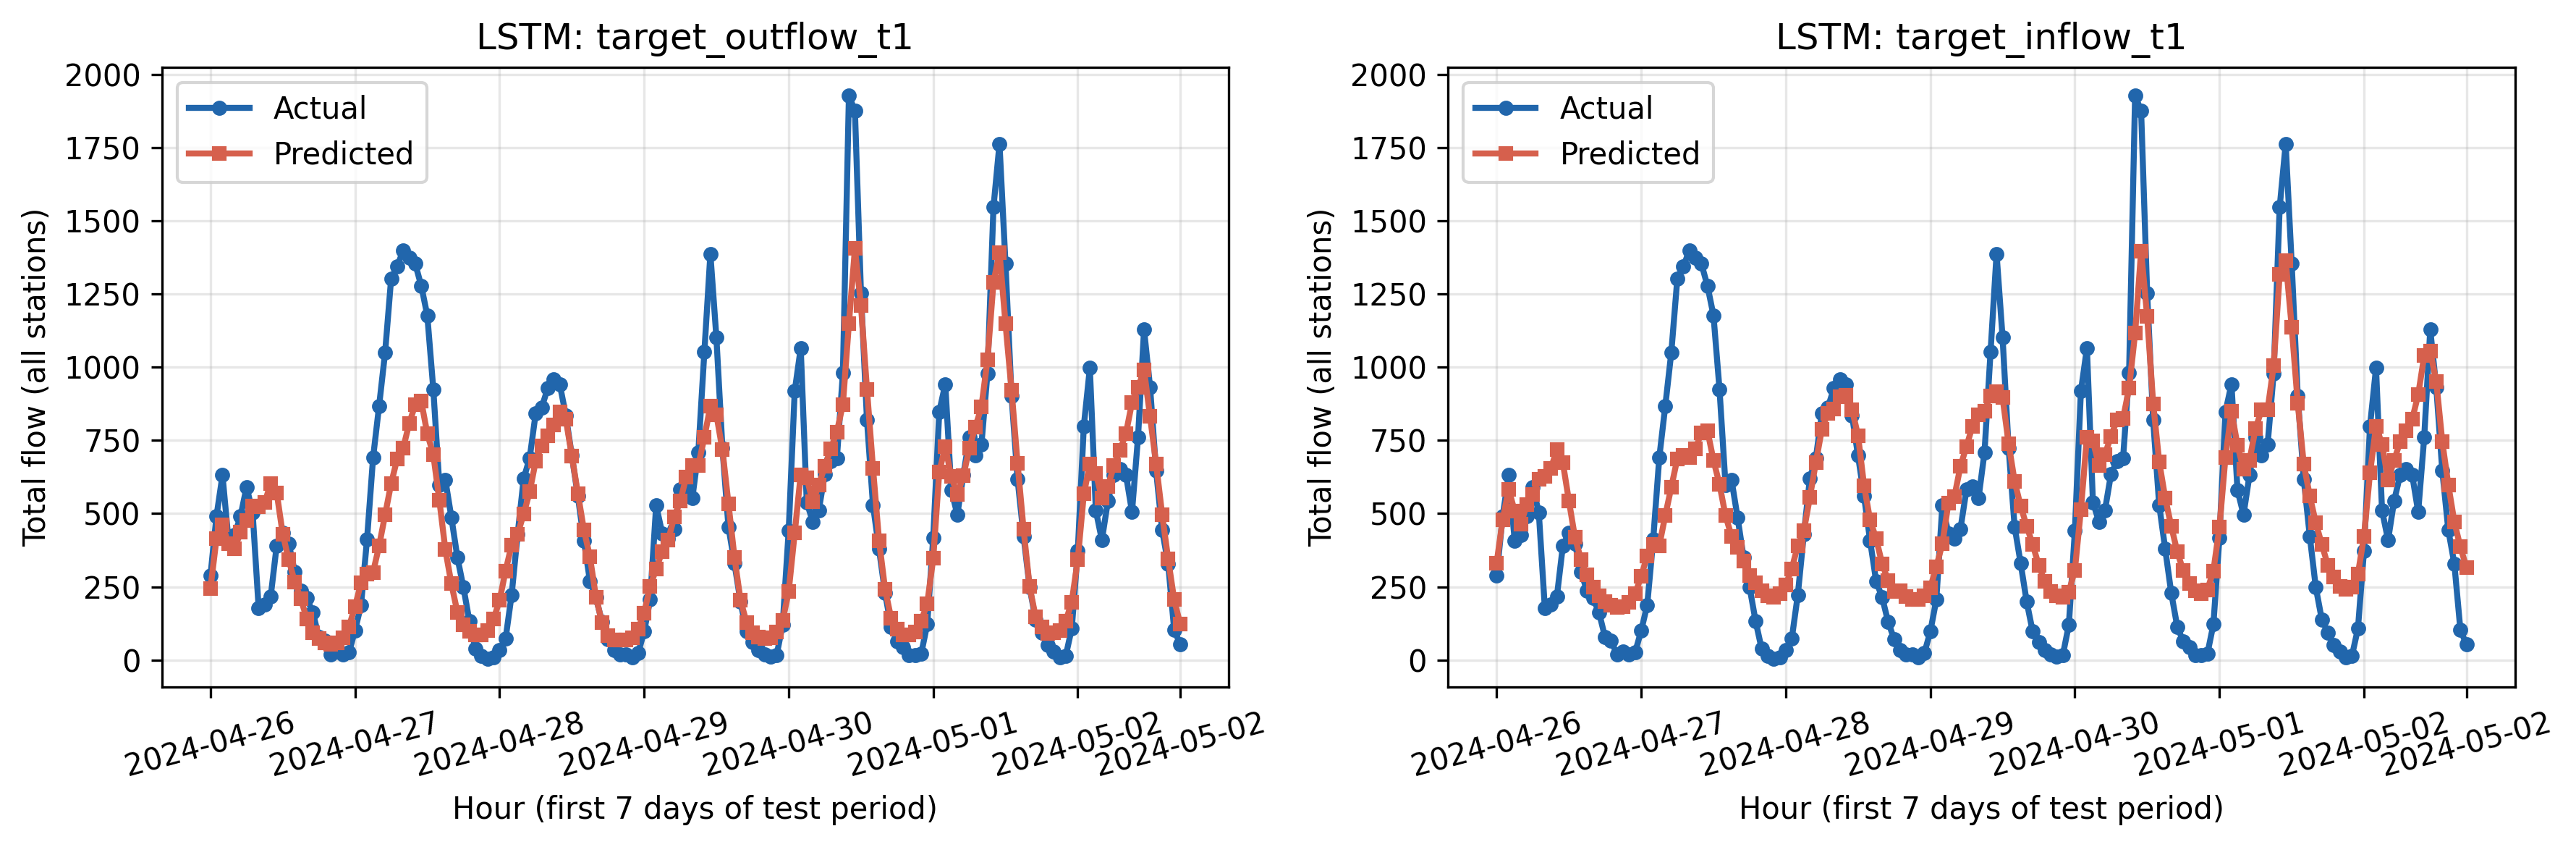

In [51]:
# --- All stations: total flow by hour — Actual vs Predicted ---
if "test_predictions" not in dir():
    test_predictions = {}
OUTFLOW_T1, INFLOW_T1 = "target_outflow_t1", "target_inflow_t1"
MODELS_ORDER = ["LSTM"]
TARGETS_ORDER = [OUTFLOW_T1, INFLOW_T1]
COLOR_ACTUAL, COLOR_PRED = "#2166AC", "#D6604D"
for model_name in MODELS_ORDER:
    print(f"{model_name}: All stations — total flow by hour (Actual vs Predicted)")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=300)
    for col, target in enumerate(TARGETS_ORDER):
        key = (model_name, target)
        ax = axes[col]
        df_vis = test_predictions[key]
        actual_col = [c for c in df_vis.columns if c not in ("station_id", "date", "hour", "pred")][0]
        first_3_dates = sorted(df_vis["date"].unique())[:7]
        df_3d = df_vis[df_vis["date"].isin(first_3_dates)]
        hourly = df_3d.groupby(["date", "hour"]).agg(actual=(actual_col, "sum"), pred=("pred", "sum")).reset_index()
        hourly = hourly.sort_values(["date", "hour"]).reset_index(drop=True)
        x = np.arange(len(hourly))
        ax.plot(x, hourly["actual"], color=COLOR_ACTUAL, label="Actual", lw=2, marker="o", markersize=4)
        ax.plot(x, hourly["pred"], color=COLOR_PRED, label="Predicted", lw=2, marker="s", markersize=4)
        tick_pos = list(range(0, len(hourly), 24))
        if len(hourly) - 1 not in tick_pos and len(hourly) > 0:
            tick_pos.append(len(hourly) - 1)
        ax.set_xticks(tick_pos)
        ax.set_xticklabels([str(hourly.iloc[i]["date"]) if i < len(hourly) else "" for i in tick_pos], rotation=15)
        ax.set_xlabel("Hour (first 7 days of test period)")
        ax.set_ylabel("Total flow (all stations)")
        ax.set_title(f"{model_name}: {target}")
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
